In [1]:
print('ok')

ok


<img src="assets/Info_v2.png">

### Buisness Objective
The objective of this analysis is to understand the factors affecting churn of account holders. By understanding resons behind why customer moves towards churn allows to create retention plans, adjust pricing, improve service on the high risk segment regions using `shubh0799/churn-modelling` dataset from kaggle.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubh0799/churn-modelling")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hasan\.cache\kagglehub\datasets\shubh0799\churn-modelling\versions\1


In [3]:
import os

os.listdir(path)

['Churn_Modelling.csv']

In [4]:
import pandas as pd 
import os

dataset = pd.read_csv(os.path.join(path, os.listdir(path)[0])).drop('RowNumber', axis=1)
print(dataset.shape)
dataset.head()

(10000, 13)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df = dataset.copy()
df.shape    

(10000, 13)

In [6]:
df.dtypes

CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
df.isna().sum()

CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
', '.join([f'`{feature}`' for feature in df.columns])

'`CustomerId`, `Surname`, `CreditScore`, `Geography`, `Gender`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`, `Exited`'

In [9]:
[print(f'`{feature}`') for feature in df.columns]

`CustomerId`
`Surname`
`CreditScore`
`Geography`
`Gender`
`Age`
`Tenure`
`Balance`
`NumOfProducts`
`HasCrCard`
`IsActiveMember`
`EstimatedSalary`
`Exited`


[None, None, None, None, None, None, None, None, None, None, None, None, None]

In [10]:
[print(f'`{df[feature].dtype}`') for feature in df.columns]

`int64`
`str`
`int64`
`str`
`str`
`int64`
`int64`
`float64`
`int64`
`int64`
`int64`
`float64`
`int64`


[None, None, None, None, None, None, None, None, None, None, None, None, None]

### Data Overview 
There are `10,000` records with demographic details( `Surname`, `Gender`, `Age`, `Geography`, `EstimatedSalary` ), account details( `CustomerId`, `CreditScore`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember` ) and target( `Exited` ) with zero incomplete records. 

|Feature            |Type       |Description
|-------------------|-----------|------------
|`CustomerId`       |`integer`  |Unique Identification Number for customer provided by bank.
|`Surname`          |`string`   |Last name of Customer.
|`CreditScore`      |`integer`  |Credit Score of the account holder.
|`Geography`        |`string`   |Country where the account holder is having account. 
|`Gender`           |`string`   |Gender of the account holder. 
|`Age`              |`integer`  |Age of the account holder.
|`Tenure`           |`integer`  |Total number of years account holder is connected.
|`Balance`          |`float`    |current balance of account holder.
|`NumOfProducts`    |`integer`  |Number of bank product/services account holder is connected.
|`HasCrCard`        |`integer`  |`0` for customer not carries bank credit card, `1` for customer carries bank credit card.
|`IsActiveMember`   |`integer`  |`0` for customer is not an active member, `1` for customer is an active number.
|`EstimatedSalary`  |`float`    |Estimated salary of the account holder.
|`Exited`           |`integer`  |`0` for customer retained, `1` for customer churned. 

##### Data Cleaning

In [11]:
df = df.drop(['CustomerId', 'Surname'], axis=1)
df.shape

(10000, 11)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.shape

(10000, 11)

In [14]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [15]:
# drop incomplete records
df = df.dropna(axis=0)
df.shape

(10000, 11)

In [16]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [17]:
df.Geography.unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [18]:
df.Gender.unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [19]:
for feature in df.columns: 
    print(feature, ',', df[feature].dtype)
    print('-'*(len(feature)+10))
    print(df[feature].unique().tolist()[:2])
    print('='*50, end='\n\n')

CreditScore , int64
---------------------
[619, 608]

Geography , str
-------------------
['France', 'Spain']

Gender , str
----------------
['Female', 'Male']

Age , int64
-------------
[42, 41]

Tenure , int64
----------------
[2, 1]

Balance , float64
-----------------
[0.0, 83807.86]

NumOfProducts , int64
-----------------------
[1, 3]

HasCrCard , int64
-------------------
[1, 0]

IsActiveMember , int64
------------------------
[1, 0]

EstimatedSalary , float64
-------------------------
[101348.88, 112542.58]

Exited , int64
----------------
[1, 0]



### Univariate Analysis

In [20]:
isinstance(df.Geography.dtype, pd.StringDtype)

True

In [21]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [22]:
target_feature = 'Exited'
target_feature

'Exited'

In [23]:
cat_features = [feature for feature in df.columns if isinstance(df[feature].dtype, pd.StringDtype) and feature!=target_feature]
num_features = [feature for feature in df.columns if feature not in cat_features and feature!=target_feature]
print(f'There are {len(num_features)} numerical features and {len(cat_features)} categorical features.')

There are 8 numerical features and 2 categorical features.


In [24]:
cat_features

['Geography', 'Gender']

In [25]:
num_features

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [26]:
descrete_features = [feature for feature in num_features if len(df[feature].unique())<20]
continuous_features = [feature for feature in num_features if feature not in descrete_features]
print(f'There are {len(descrete_features)} descrete numerical features and {len(continuous_features)} continuous numerical features.')

There are 4 descrete numerical features and 4 continuous numerical features.


In [27]:
descrete_features

['Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

In [28]:
continuous_features

['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

In [29]:
import matplotlib.pyplot as plt 

%matplotlib inline

In [30]:
from random import choice
import math 

In [31]:
nrows, ncols =  math.ceil(len(df.columns)/3), 3
nrows, ncols

(4, 3)

In [32]:
import seaborn as sns 

In [33]:
colors = [
    # Tableau 10 (Standard, high-contrast)
    'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 
    'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
    
    # Curated XKCD (Descriptive, soft, and modern)
    'xkcd:royal blue', 'xkcd:sage green', 'xkcd:terracotta', 
    'xkcd:dusty purple', 'xkcd:muted pink', 'xkcd:deep aqua', 
    'xkcd:goldenrod', 'xkcd:slate blue', 'xkcd:crimson', 'xkcd:dark teal'
]
colors

['tab:blue',
 'tab:orange',
 'tab:green',
 'tab:red',
 'tab:purple',
 'tab:brown',
 'tab:pink',
 'tab:gray',
 'tab:olive',
 'tab:cyan',
 'xkcd:royal blue',
 'xkcd:sage green',
 'xkcd:terracotta',
 'xkcd:dusty purple',
 'xkcd:muted pink',
 'xkcd:deep aqua',
 'xkcd:goldenrod',
 'xkcd:slate blue',
 'xkcd:crimson',
 'xkcd:dark teal']

In [34]:
dict_palette = {}

keys = set()
for feature in (descrete_features+cat_features):
    for key in df[feature].unique():
        keys.add(key)

for key in keys:
    dict_palette[key] = choice(colors) 
    colors.remove(dict_palette[key])

dict_palette

{np.int64(0): 'xkcd:slate blue',
 np.int64(1): 'xkcd:sage green',
 np.int64(2): 'xkcd:dusty purple',
 np.int64(3): 'xkcd:royal blue',
 np.int64(4): 'xkcd:dark teal',
 np.int64(5): 'xkcd:terracotta',
 np.int64(6): 'xkcd:crimson',
 np.int64(7): 'xkcd:goldenrod',
 np.int64(8): 'xkcd:muted pink',
 np.int64(9): 'tab:gray',
 np.int64(10): 'tab:red',
 'France': 'tab:brown',
 'Germany': 'xkcd:deep aqua',
 'Male': 'tab:purple',
 'Spain': 'tab:blue',
 'Female': 'tab:olive'}

In [35]:
# plt.pie(
#     x=df.Geography.value_counts().values, 
#     labels=df.Geography.value_counts().index, 
#     colors={dict_palette[i] for i in df.Geography.value_counts().index}, 
#     autopct='%1.1f%%',
#     startangle=90
# )
# plt.xlabel('Geography')
# plt.show()

In [36]:
from typing import Iterable

In [37]:
def create_univariate_chart(
        nrows: int, 
        ncols: int, 
        df: pd.DataFrame, 
        features_for_ploting: Iterable, 
        cat_features: Iterable, 
        descrete_features: Iterable, 
        continuous_features: Iterable, 
        target_feature: str, 
        dict_palette: dict[str, str], 
        path: str = "reports/Univariate Analysis.png", 
        figsize: tuple = (30, 20), 
        header_fontsize: int = 20
): 
    # Univariate Analysis
    colors = [
        # Tableau 10 (Standard, high-contrast)
        'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 
        'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan',
        
        # Curated XKCD (Descriptive, soft, and modern)
        'xkcd:royal blue', 'xkcd:sage green', 'xkcd:terracotta', 
        'xkcd:dusty purple', 'xkcd:muted pink', 'xkcd:deep aqua', 
        'xkcd:goldenrod', 'xkcd:slate blue', 'xkcd:crimson', 'xkcd:dark teal'
    ]
    fig, axis = plt.subplots(nrows, ncols, figsize=figsize)
    fig.suptitle("Univariate Analysis", fontsize=header_fontsize, fontweight="bold", color="r", fontstyle="oblique", y=1)
    idx=0
    stop=False
    for row in range(nrows):
        for col in range(ncols):
            feature = features_for_ploting[idx]
            ax = axis[row, col]
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if feature in cat_features or feature in descrete_features:
                sns.countplot(df, x=feature, ax=ax, hue=feature, palette=dict_palette, legend=False)
            if feature==target_feature:
                ax.pie(
                    x=df[feature].value_counts().values, 
                    labels=df[feature].value_counts().index, 
                    colors=[dict_palette[i] for i in df[feature].value_counts().index], 
                    autopct='%1.1f%%', 
                    radius=1.2
                )
                ax.set_xlabel(feature)
            if feature in continuous_features: 
                c = choice(colors)
                colors.remove(c)
                sns.histplot(df, x=feature, kde=True, ax=ax, color=c, bins=10)
                del c
            idx+=1
            if idx==len(features_for_ploting):
                stop=True
                break
        if stop:
            break
    for row in axis:
        for ax in row:
            if not ax.has_data():
                ax.remove()
    plt.tight_layout()

    # Save a high-resolution, neatly framed, transparent PNG file
    plt.savefig(path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

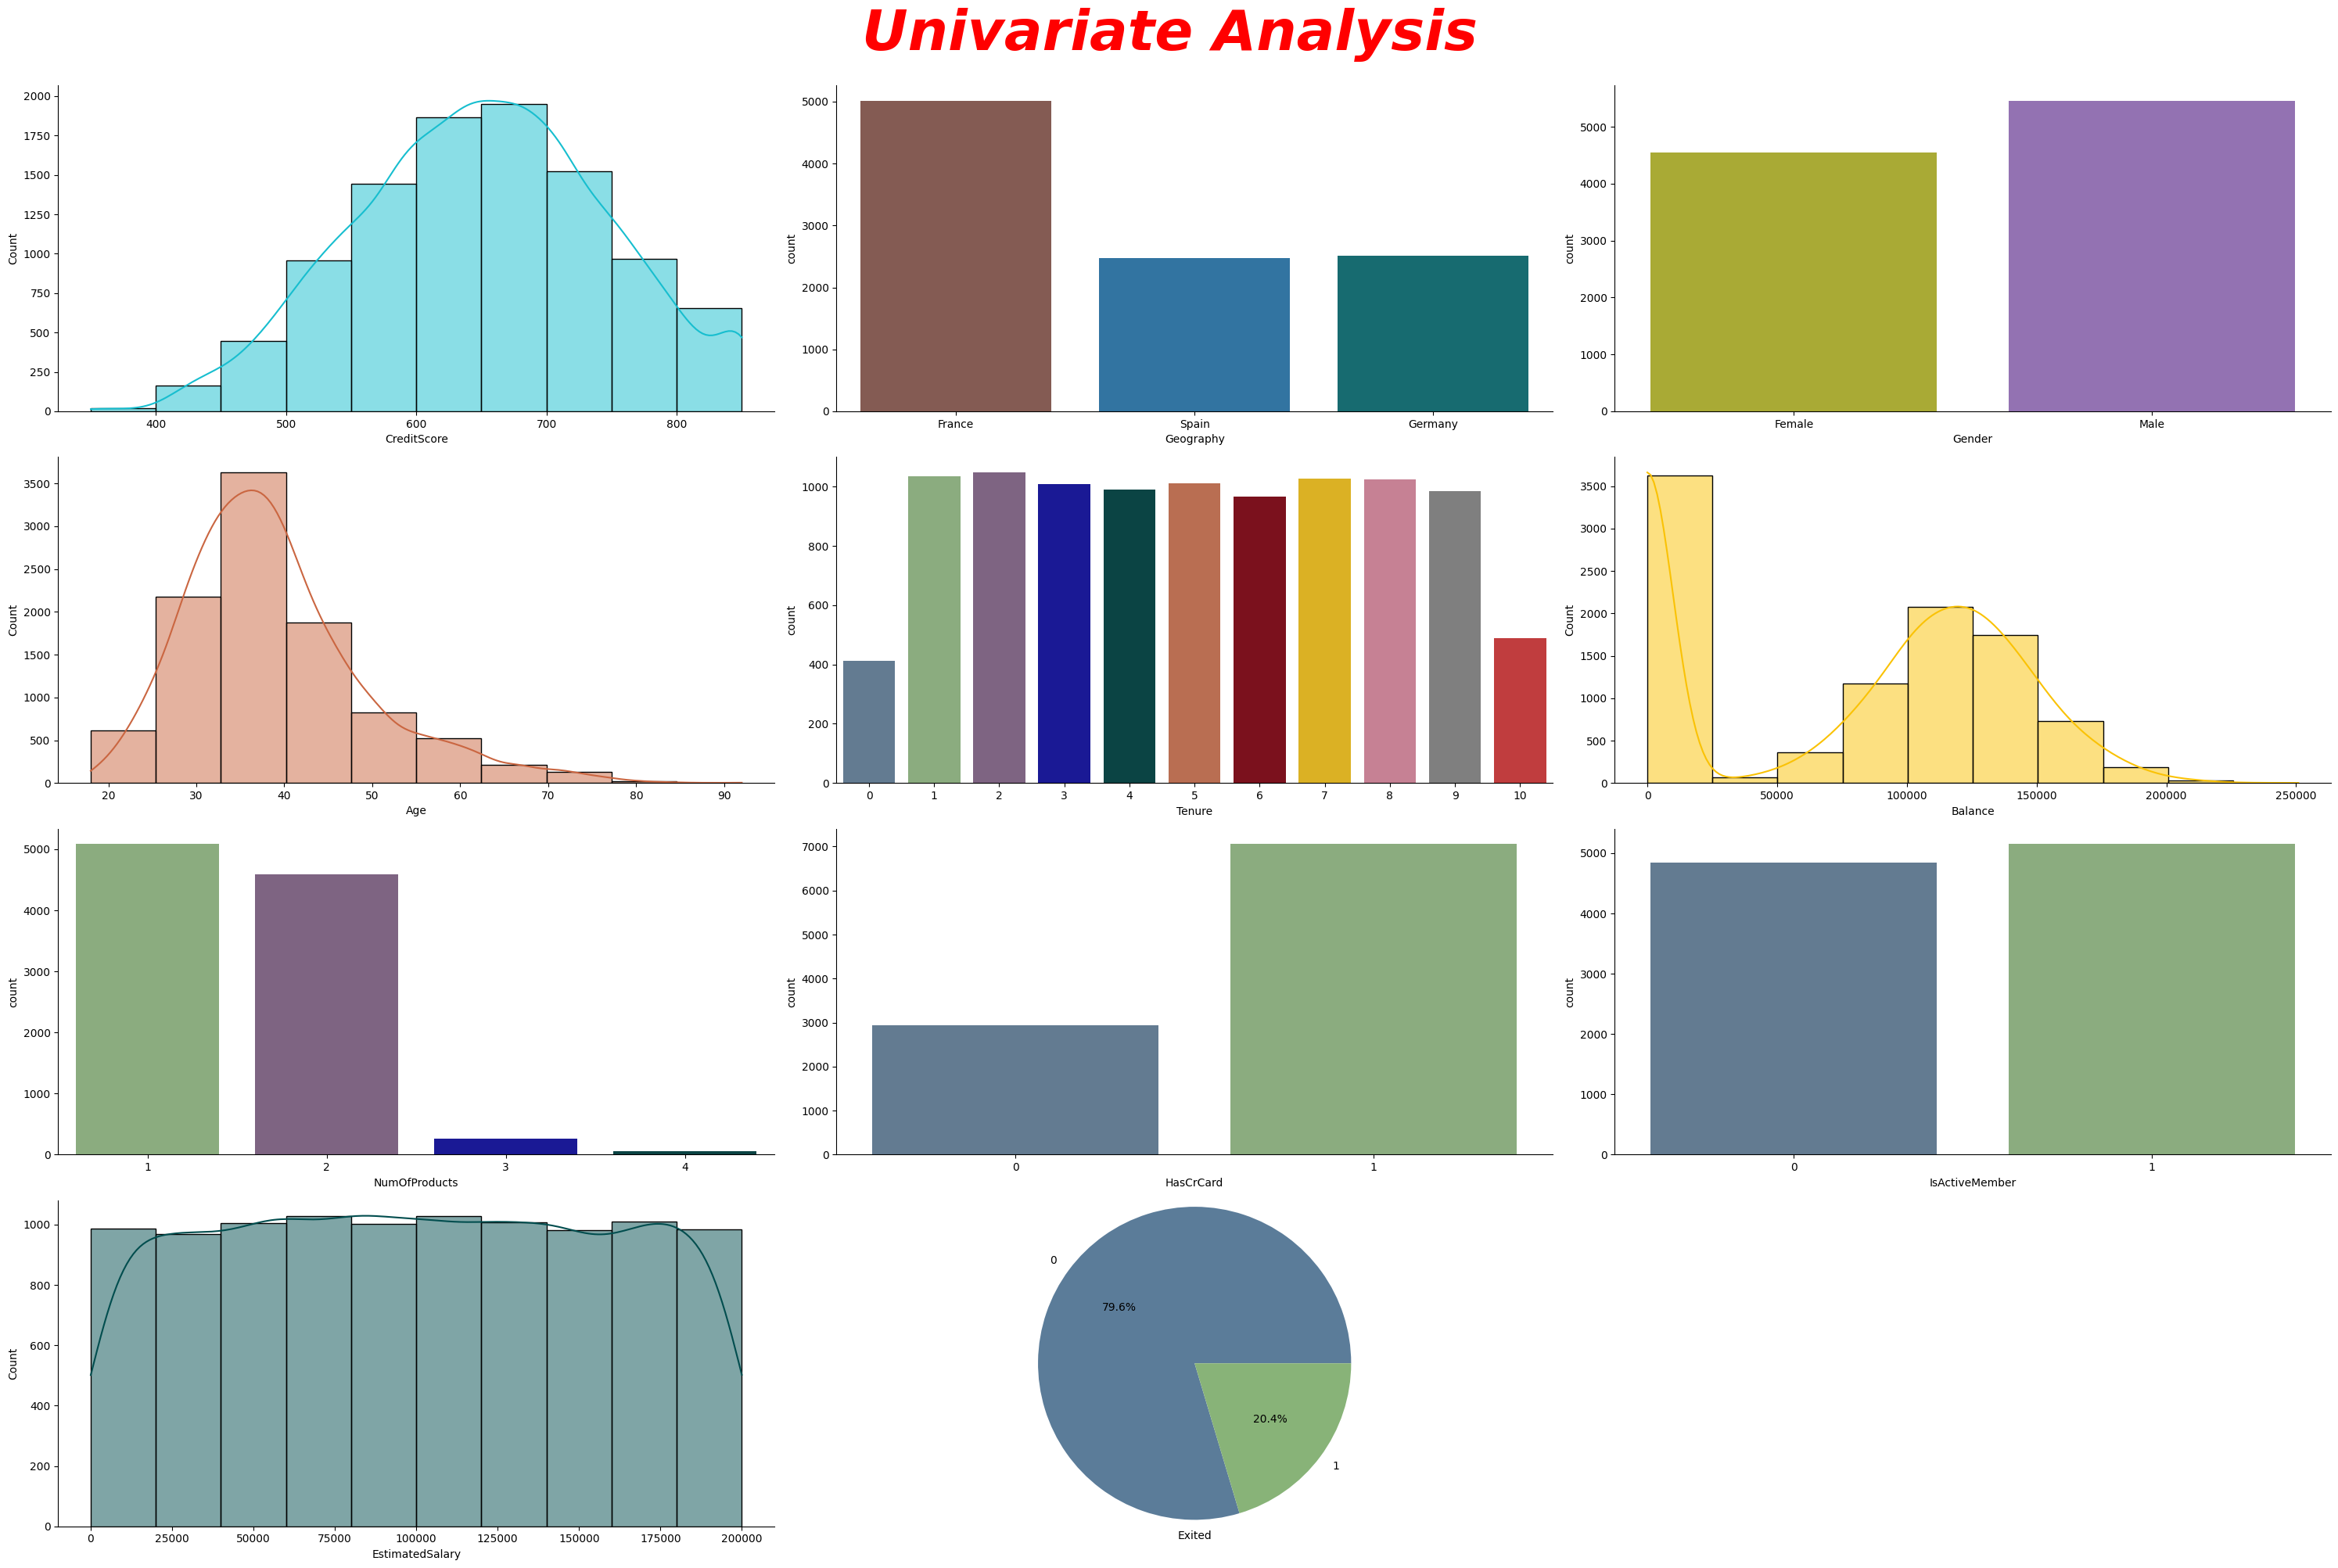

In [38]:
create_univariate_chart(
        nrows=nrows, 
        ncols=ncols, 
        df=df, 
        features_for_ploting=df.columns, 
        cat_features=cat_features, 
        descrete_features=descrete_features, 
        continuous_features=continuous_features, 
        target_feature=target_feature, 
        dict_palette=dict_palette, 
        header_fontsize=52
)

In [39]:
# age, balance, numofproducts and exited

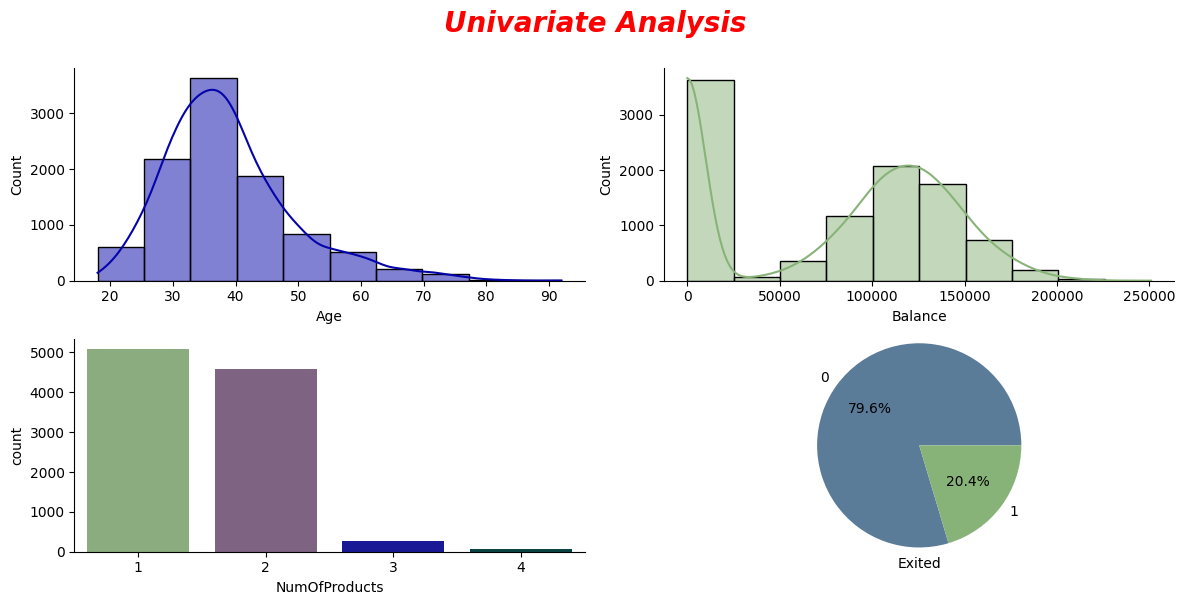

In [40]:
create_univariate_chart(
        nrows=2, 
        ncols=2, 
        df=df, 
        features_for_ploting= ['Age', 'Balance', 'NumOfProducts', 'Exited'], 
        cat_features=cat_features, 
        descrete_features=descrete_features, 
        continuous_features=continuous_features, 
        target_feature=target_feature, 
        dict_palette=dict_palette, 
        path="reports/Univariate Analysis Final Dashboard.png", 
        figsize=(12, 6)
)

### Observation 

Distribution of Age is skewed towards right. There is a big spike on Balance distribution at raange 0-25k and then it follows normal distribution. We are having a very less customers holding 3 products where only few . This dataset show 20% of churn rate. 

<!-- |Feature          |Information                                                                                            
|-                |-
|`CreditScore`    |Most of the customers are having credit score at a range of 550 to 750. 
|`Geography`      |France is have 51.1% of our total customers where germany and spain are having approximately equal. 
|`Gender`         |54.6% and 45.4% are male and female customers respectively.
|`Age`            |There are only few customers above age of 60. Majority of customers having age between 25 to 45. 
|`Tenure`         |There are 4.1% and 4.9% customers with less than 1 year and 10 years or above respectively. Tenure from 1 to 9 years are having approximately 10% of total customers. 
|`Balance`        |More than 35% of customers are having balance amount less than 25K. There is a good balance of customers having 50k - 200K where majority falls between range of 100K - 150K. 
|`NumOfProducts`  |50.8% of customers are connected with only a single product where 45.9% of customers carries two products and the rest are having 3 or 4 products in which customers with 3 products are dominating. 
|`HasCrCard`      |70.6% of customers are holding our credit card where remaining 29.4% are not. 
|`IsActiveMember` |48.5% of customers are inactive. 
|`EstimatedSalary`|We are having approximately equal number of customers in estimated salary with a range from 0 - 200K at a window of 20k. 
|`Exited`         |20.4% of our total customer already churned. -->

<!-- ***Key Findings***

51.1% of customers belongs to Germany. From total customers 54.6% are male and 45.4% are female where majority falls in between age of 25 to 45 and few are older than 60 having a range of estimated salary from 0 to 200k. Majority of customer's credit score falls under the range of 550 - 750 and 4.1% of customer are having tenure less than 1 year and 4.9% are having 10 years of tenure. More than 35% of customers are having balance less than 25k but majority falls between 100k - 150k where 96% are carrying one or two products and 48.5% are inactive memebers with a churn rate of 20.4% . -->

### Bivariate Analysis

In [41]:
df.groupby('Gender')['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})

,Gender,Churn Rate
0,Female,0.250715
1,Male,0.164559


In [42]:
def create_bivariate_chart(
    nrows: int, 
    ncols: int, 
    df: pd.DataFrame, 
    features_for_ploting: Iterable, 
    cat_features: Iterable, 
    descrete_features: Iterable, 
    continuous_features: Iterable, 
    target_feature: str, 
    dict_palette: dict[str, str], 
    path: str = "reports/Bivariate Analysis.png", 
    figsize: tuple = (30, 20), 
    header_fontsize: int = 20
): 
    # Bivariate Analysis
    fig, axis = plt.subplots(nrows, ncols, figsize=figsize)
    fig.suptitle("Bivariate Analysis", fontsize=header_fontsize, fontweight="bold", color="purple", fontstyle="oblique", y=1)
    idx=0
    stop=False
    for row in range(nrows):
        for col in range(ncols):
            feature = features_for_ploting[idx]
            ax = axis[row, col]
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if feature in cat_features or feature in descrete_features:
                agg_data = df.groupby(feature)['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})
                sns.barplot(
                    agg_data, 
                    x=feature, 
                    y='Churn Rate', 
                    hue=feature, 
                    palette=dict_palette, 
                    legend=False, 
                    ax=ax
                )
            if feature in continuous_features: 
                sns.boxplot(
                    df, 
                    x=target_feature, 
                    y=feature, 
                    hue=target_feature,
                    palette=dict_palette, 
                    legend=False, 
                    ax=ax, 
                )
            idx+=1
            if len(features_for_ploting)==idx:
                stop=True
                break
        if stop:
            break
    for row in axis:
        for ax in row:
            if not ax.has_data():
                ax.remove()
    plt.tight_layout()

    # Save a high-resolution, neatly framed, transparent PNG file
    plt.savefig(path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()



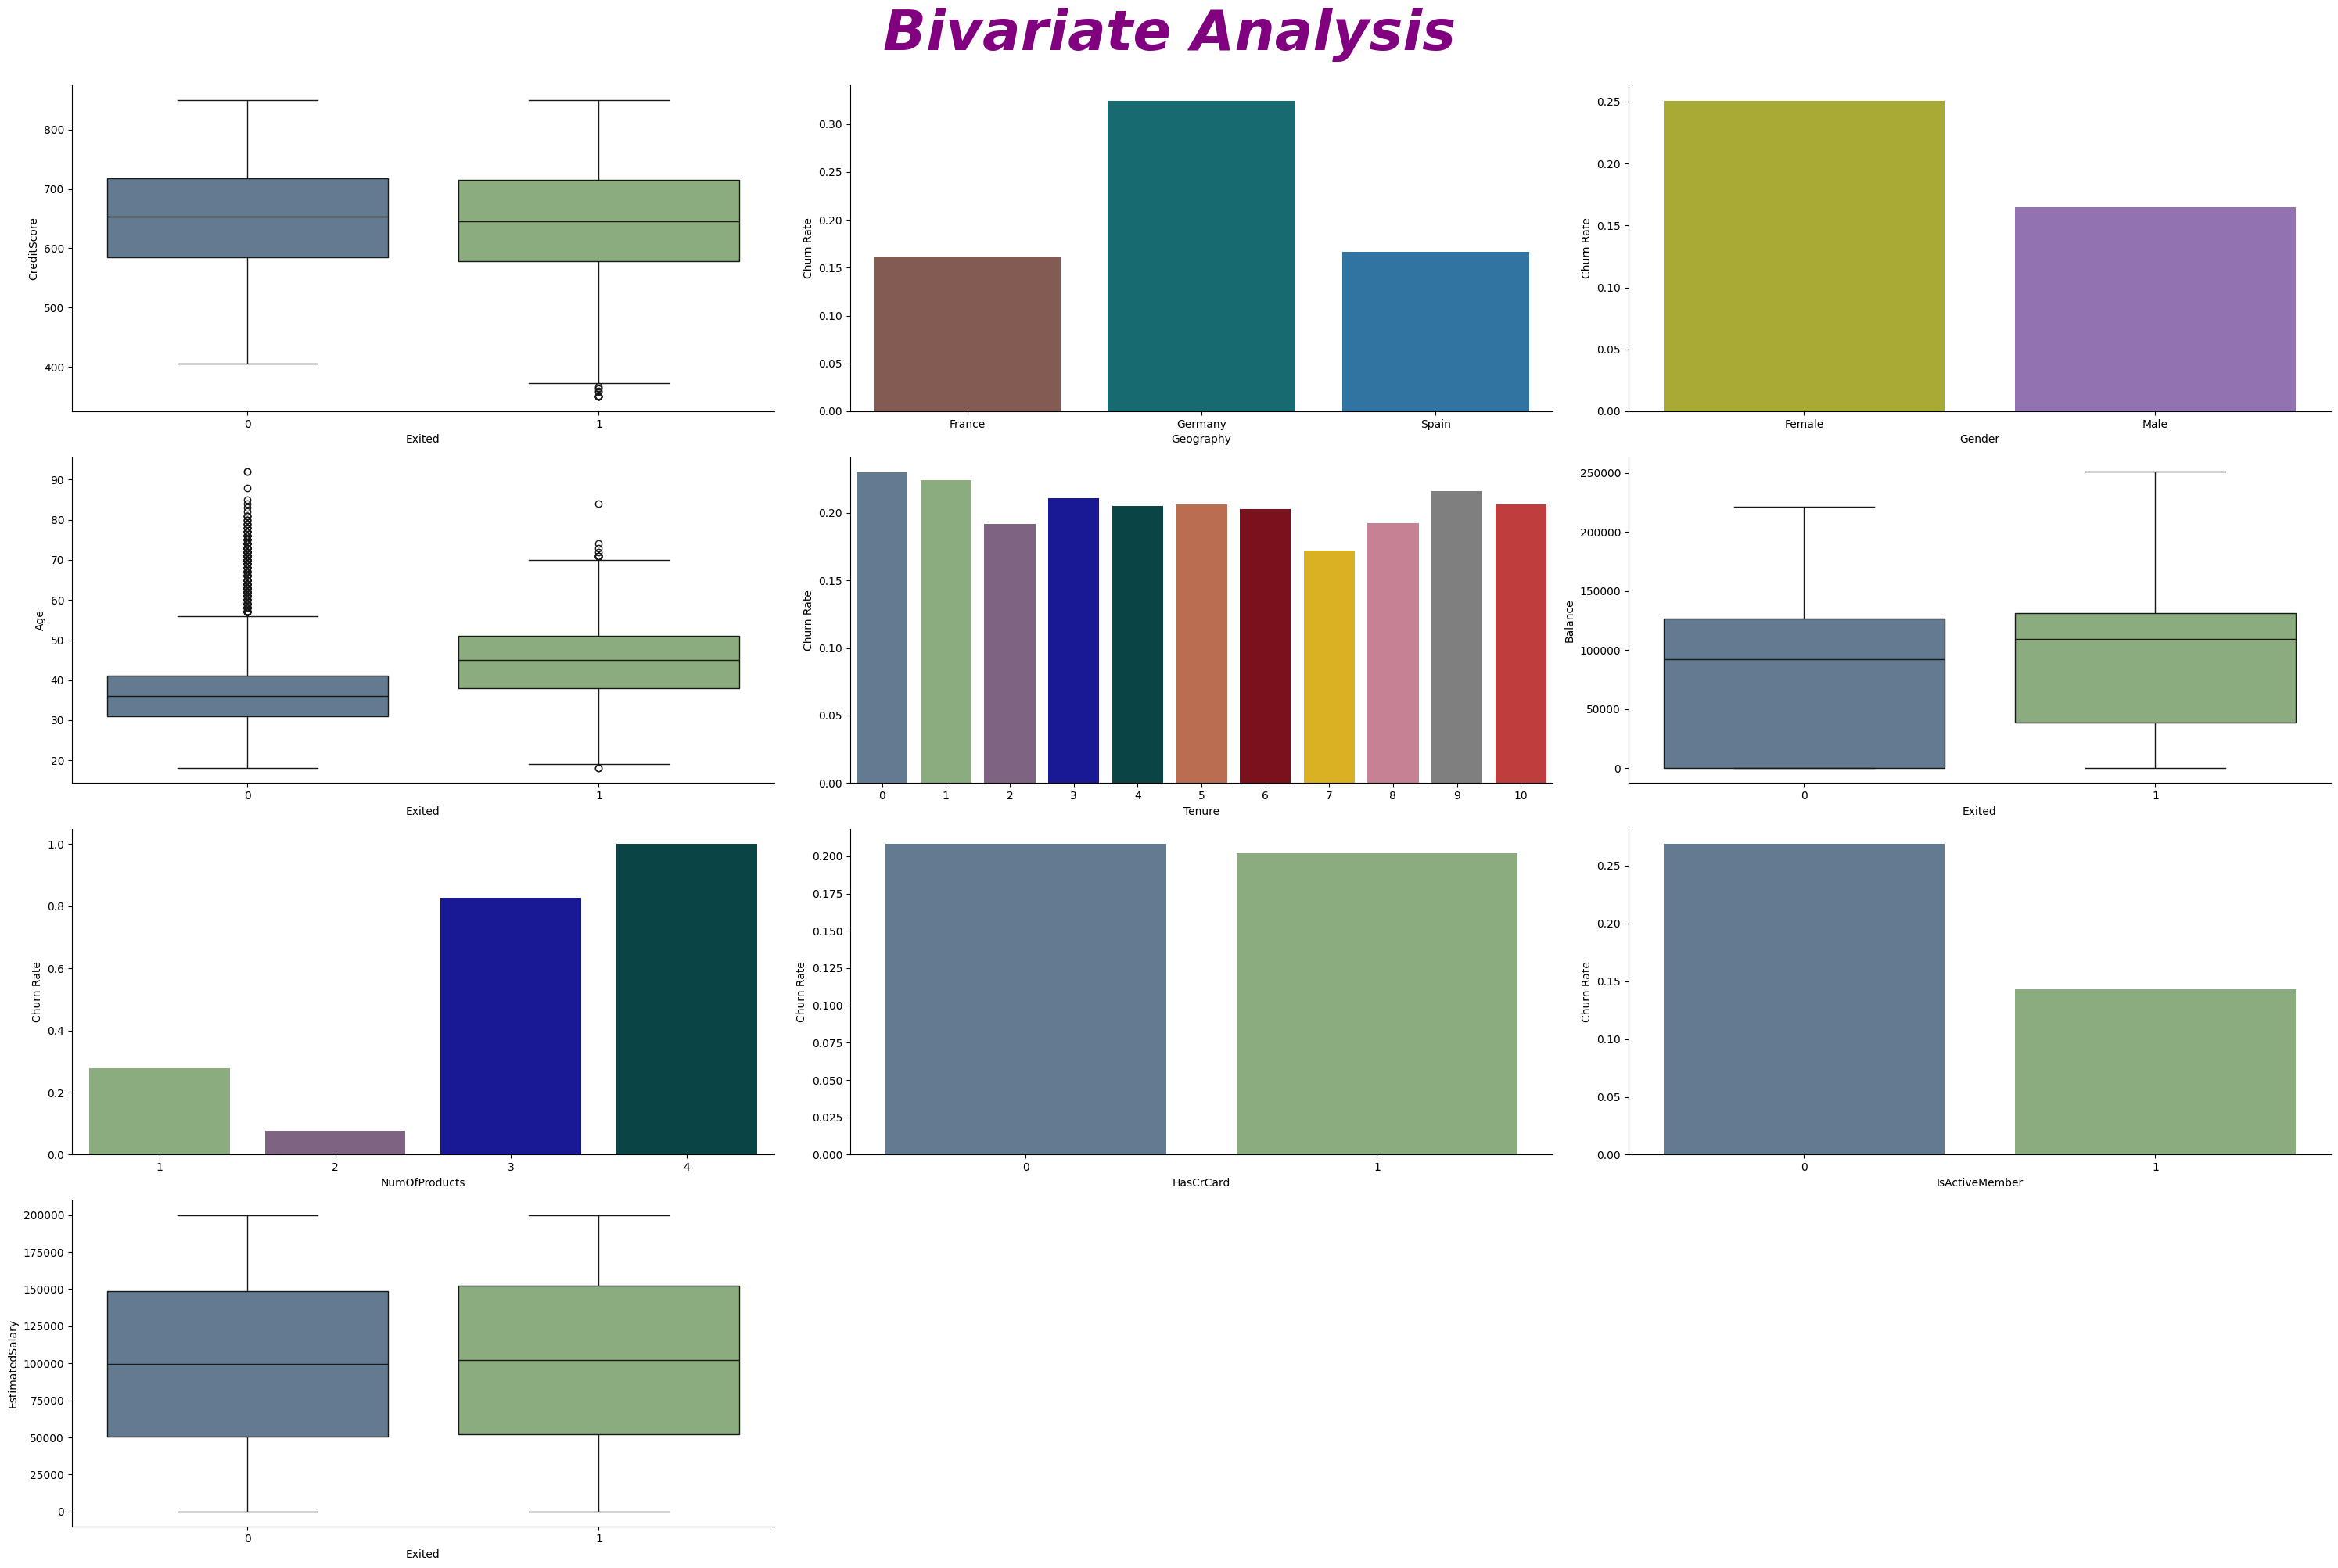

In [43]:
nrows, ncols =  math.ceil((len(df.columns)-1)/3), 3
create_bivariate_chart(
    nrows=nrows, 
    ncols=ncols, 
    df=df, 
    features_for_ploting=df.columns, 
    cat_features=cat_features, 
    descrete_features=descrete_features, 
    continuous_features=continuous_features, 
    target_feature=target_feature, 
    dict_palette=dict_palette,
    header_fontsize = 52
)

In [44]:
'''Geography, Gender, Age, Balance, NumOfProducts'''

'Geography, Gender, Age, Balance, NumOfProducts'

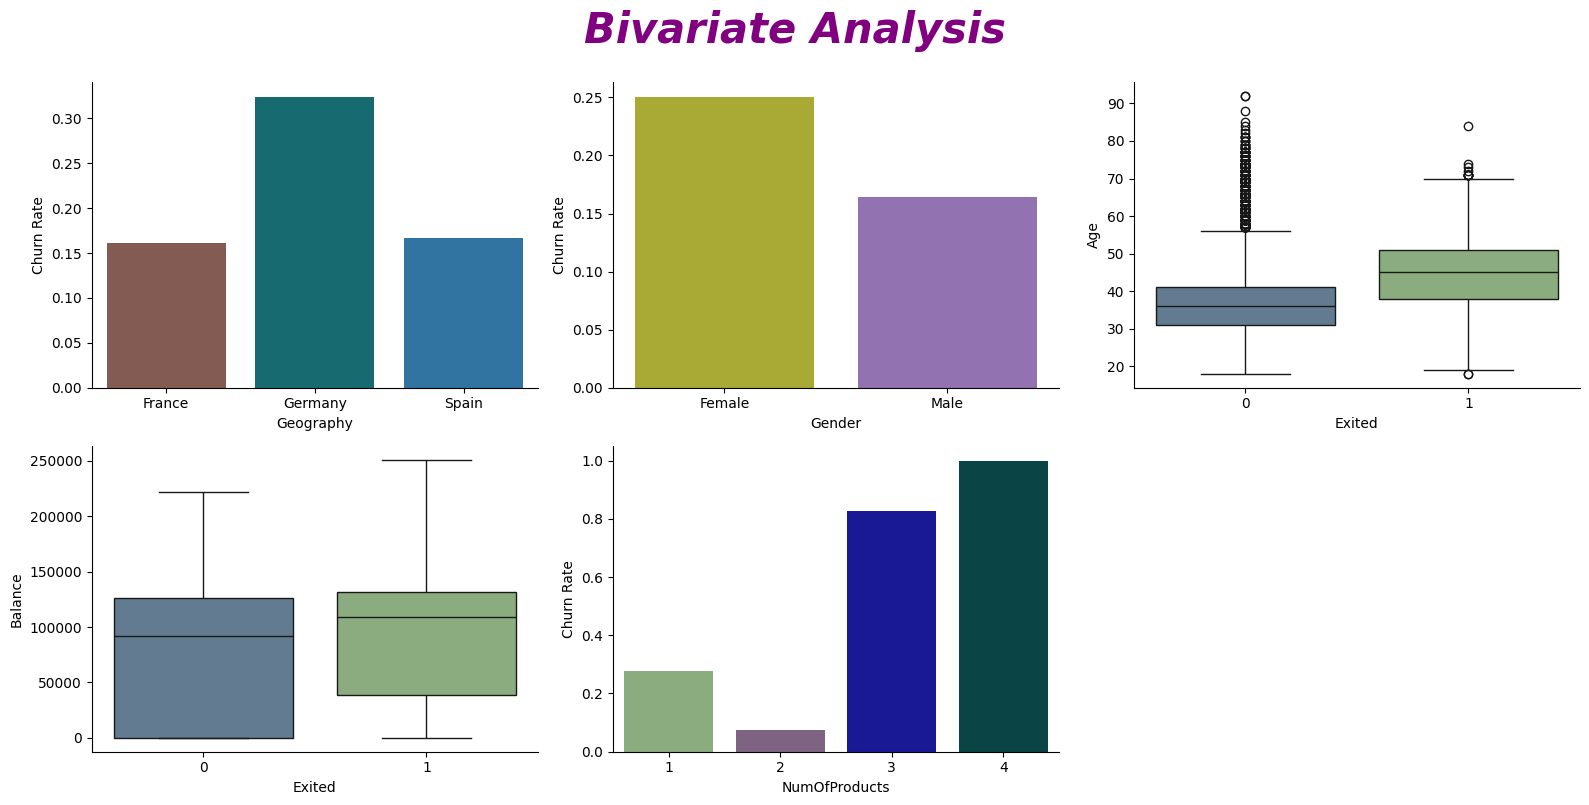

In [45]:
create_bivariate_chart(
    nrows=2, 
    ncols=3, 
    df=df, 
    features_for_ploting=['Geography', 'Gender', 'Age', 'Balance', 'NumOfProducts'], 
    cat_features=cat_features, 
    descrete_features=descrete_features, 
    continuous_features=continuous_features, 
    target_feature=target_feature, 
    dict_palette=dict_palette,
    path='reports/Bivariate Analysis Final Dashboard.png', 
    figsize=(16, 8), 
    header_fontsize=30
)

### Observation

Germany is having highest churn rate might be geographic or poor service. When looking at Gender Females higher churning rate as compare to males. People above 40 churns more. People with higher balance churns higher which potentially indicate toward poor service. When it comes to people holding number of products those who are holding more products have higher churn rate as people holding 3 products having high churn rate but people holding 4 products have churn rate even more higher. 

<!-- |Feature          |Information with respect to target variable `Exited`
|-                |-
|`CreditScore`    |CreditScore don't have any deep relation with churning of customers.
|`Geography`      |Germany have lowest customer count but having highest churn rate. 
|`Gender`         |Female having low count as compare to Male but having higher churn rate than Male.
|`Age`            |Customers with higher age are having more churn rate as compare to customers with lower age.
|`Tenure`         |Tenure don't have any deep relation with churning of customers.
|`Balance`        |Customer's with higher balance have exited more. 
|`NumOfProducts`  |Customer's holding more products having higher churn rate.
|`HasCrCard`      |Customer's having credit card have churned more.
|`IsActiveMember` |InActive members churns more as compared active one.
|`EstimatedSalary`|EstimatedSalary don't have any deep relation with churning of customers. -->

<!-- ***Key Findings***

Customer above 35 years old needed to be focussed on rataining as increase in age shows higher churn rate. Female exits more as compare to male. Germany is having highest churn rate with lowest customer count which indicates either the landmark works differently in terms of bank and its services or there is a serious service negligence issue. Customers with higher balance, holding more number of products and have credit card churns more which highly indicates poor quality of services are being provided to highly valuable customers which could be a serious concern. InActive members churns higher than active ones.  -->

### Multivariate Analysis

<Axes: >

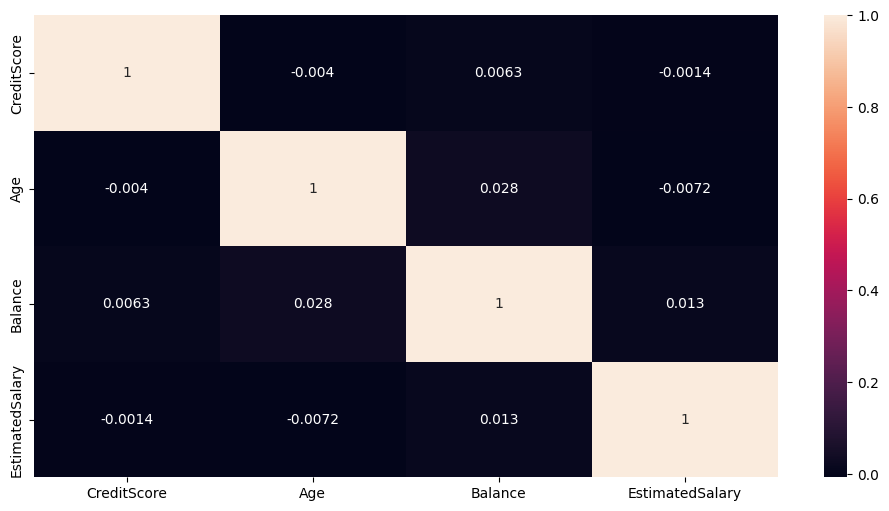

In [46]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.drop((cat_features + descrete_features + [target_feature]), axis=1).corr(), annot=True)

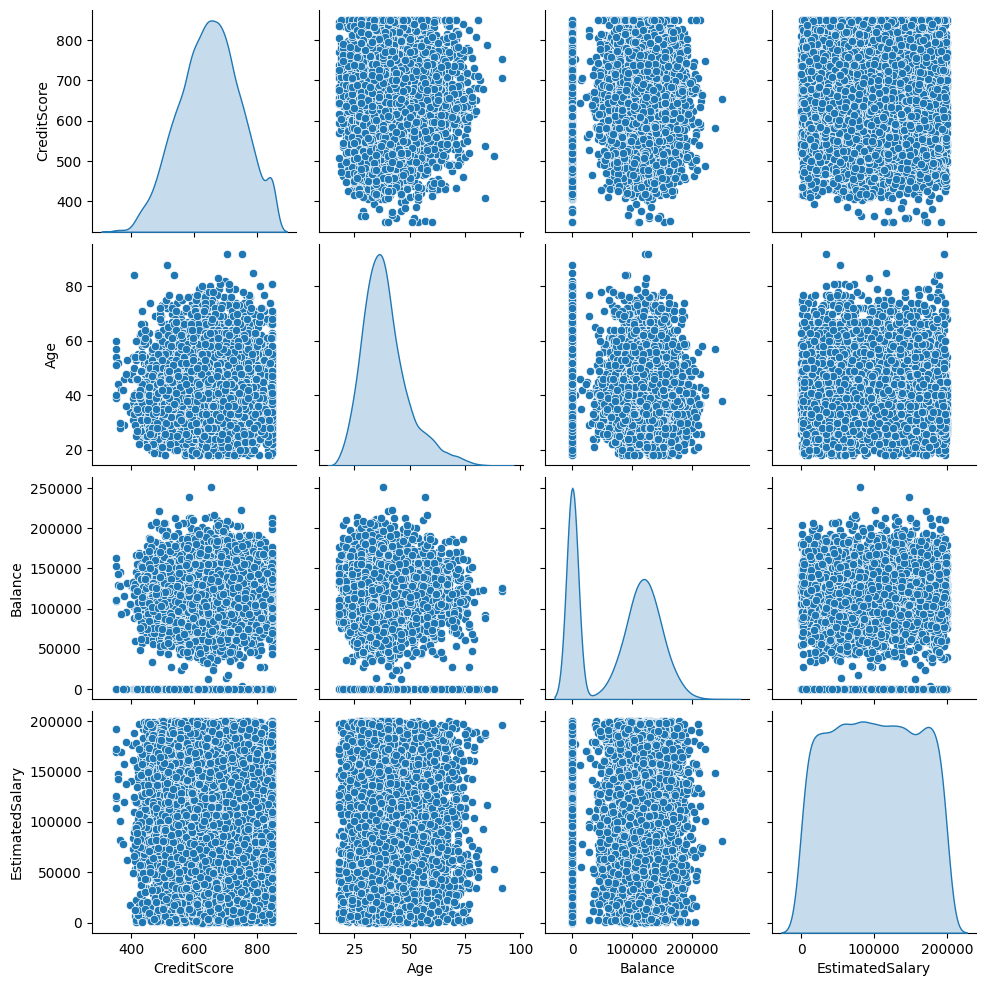

In [47]:
sns.pairplot(df[continuous_features], diag_kind='kde')

In [48]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

In [49]:
cols_with_norelation = [
    'CreditScore', 
    'Tenure', 
    'EstimatedSalary'
]
cols_with_norelation

['CreditScore', 'Tenure', 'EstimatedSalary']

In [50]:
from itertools import combinations

cols_combinations = list(combinations([feature for feature in df.columns if feature not in cols_with_norelation and feature!=target_feature and feature!='IsActiveMember'], 2))
len(cols_combinations), cols_combinations

(15,
 [('Geography', 'Gender'),
  ('Geography', 'Age'),
  ('Geography', 'Balance'),
  ('Geography', 'NumOfProducts'),
  ('Geography', 'HasCrCard'),
  ('Gender', 'Age'),
  ('Gender', 'Balance'),
  ('Gender', 'NumOfProducts'),
  ('Gender', 'HasCrCard'),
  ('Age', 'Balance'),
  ('Age', 'NumOfProducts'),
  ('Age', 'HasCrCard'),
  ('Balance', 'NumOfProducts'),
  ('Balance', 'HasCrCard'),
  ('NumOfProducts', 'HasCrCard')])

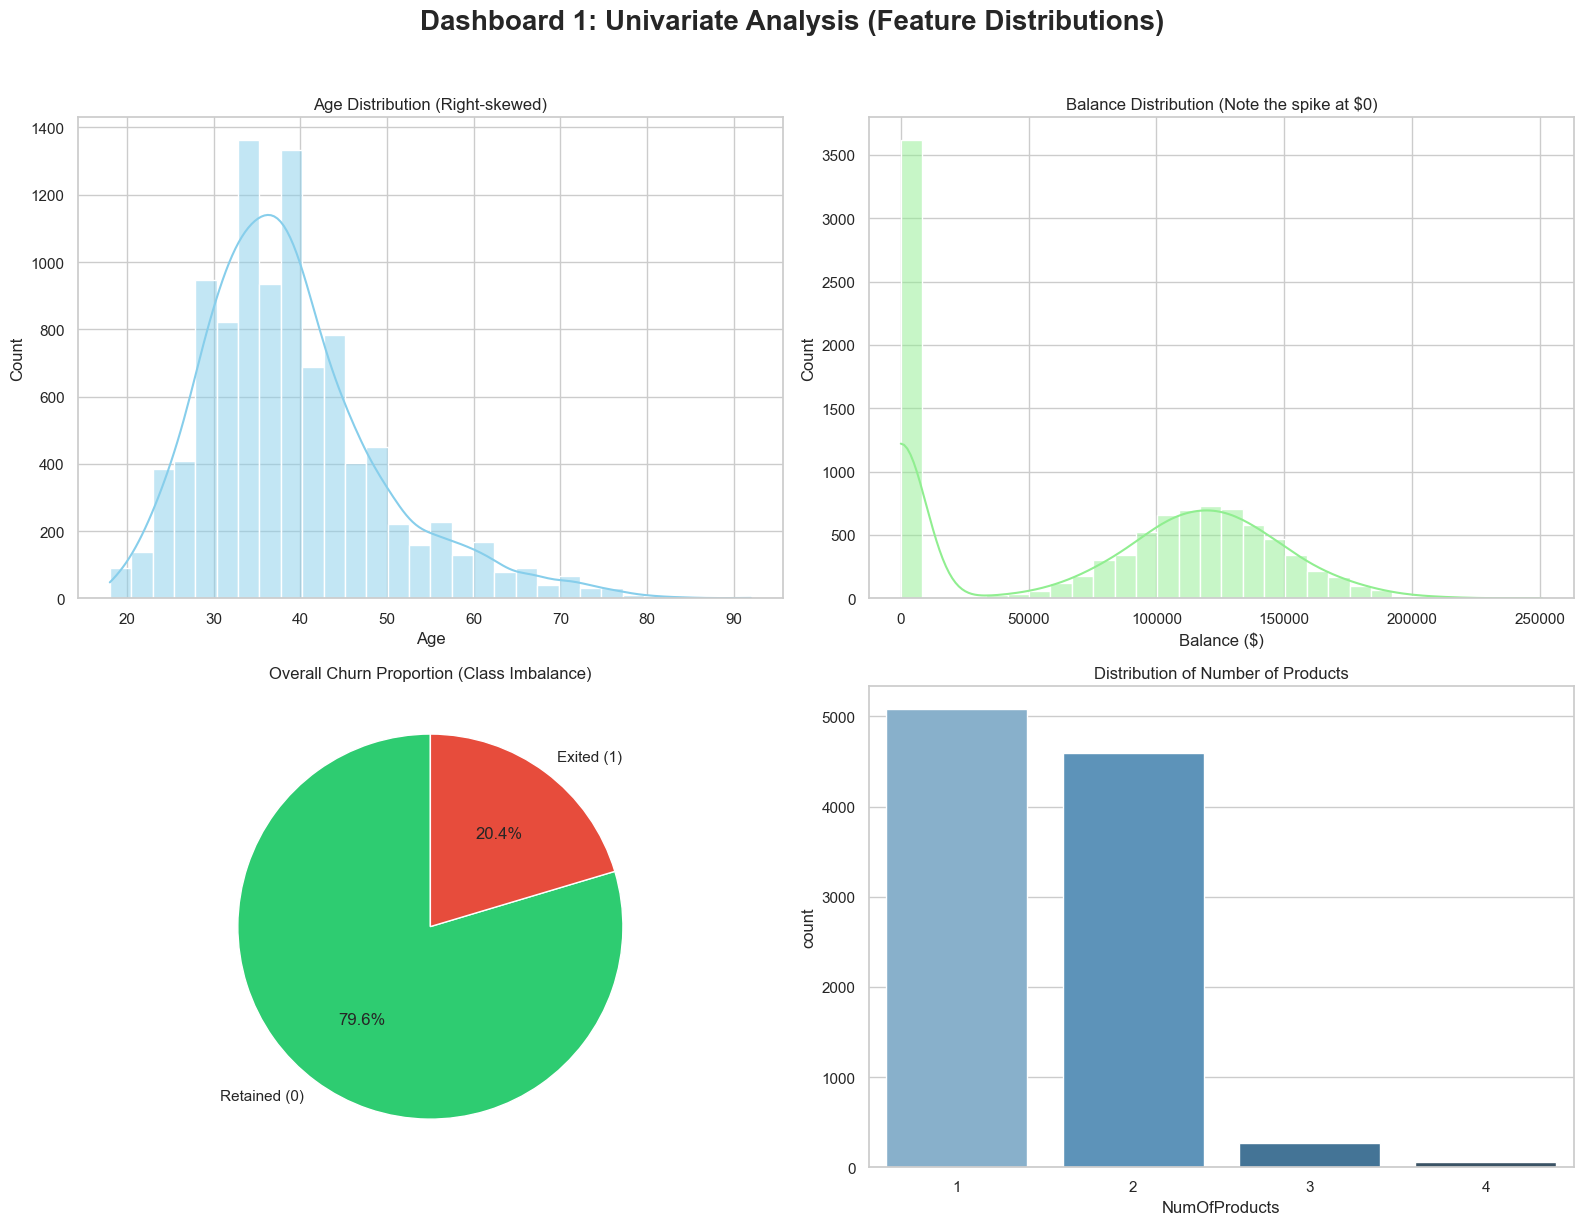

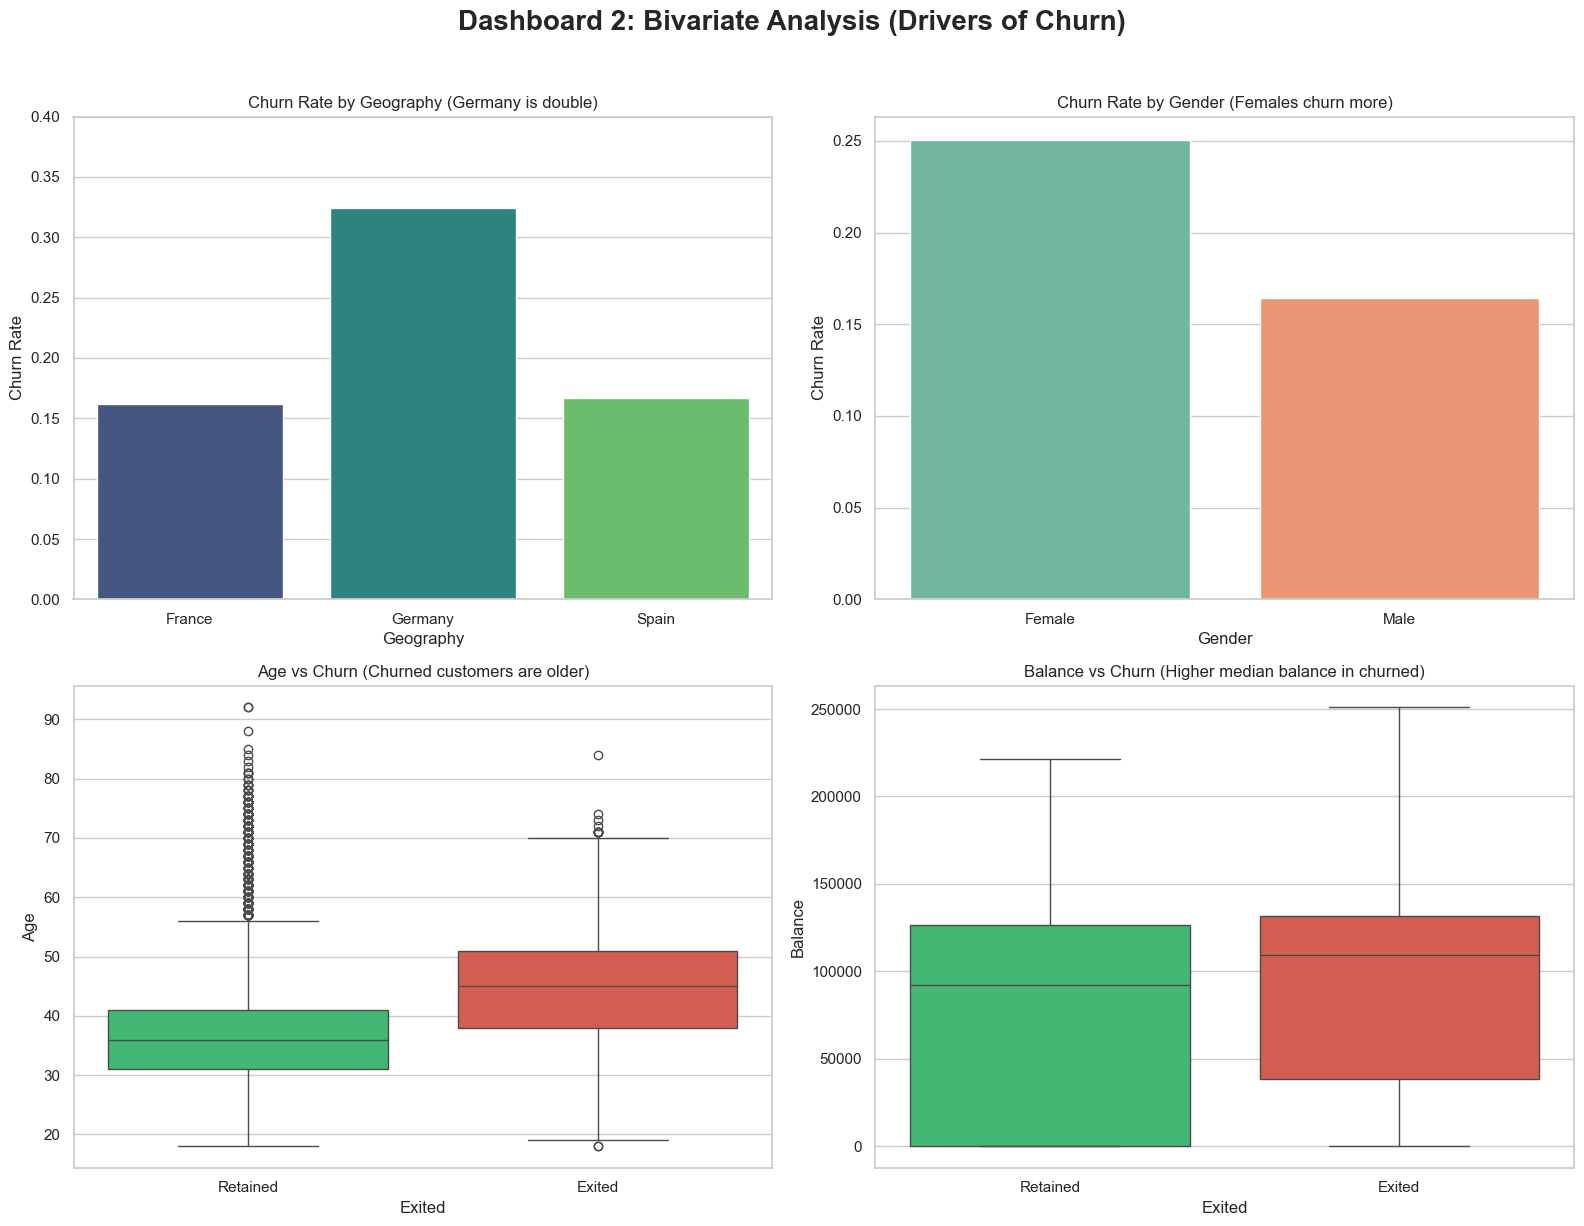

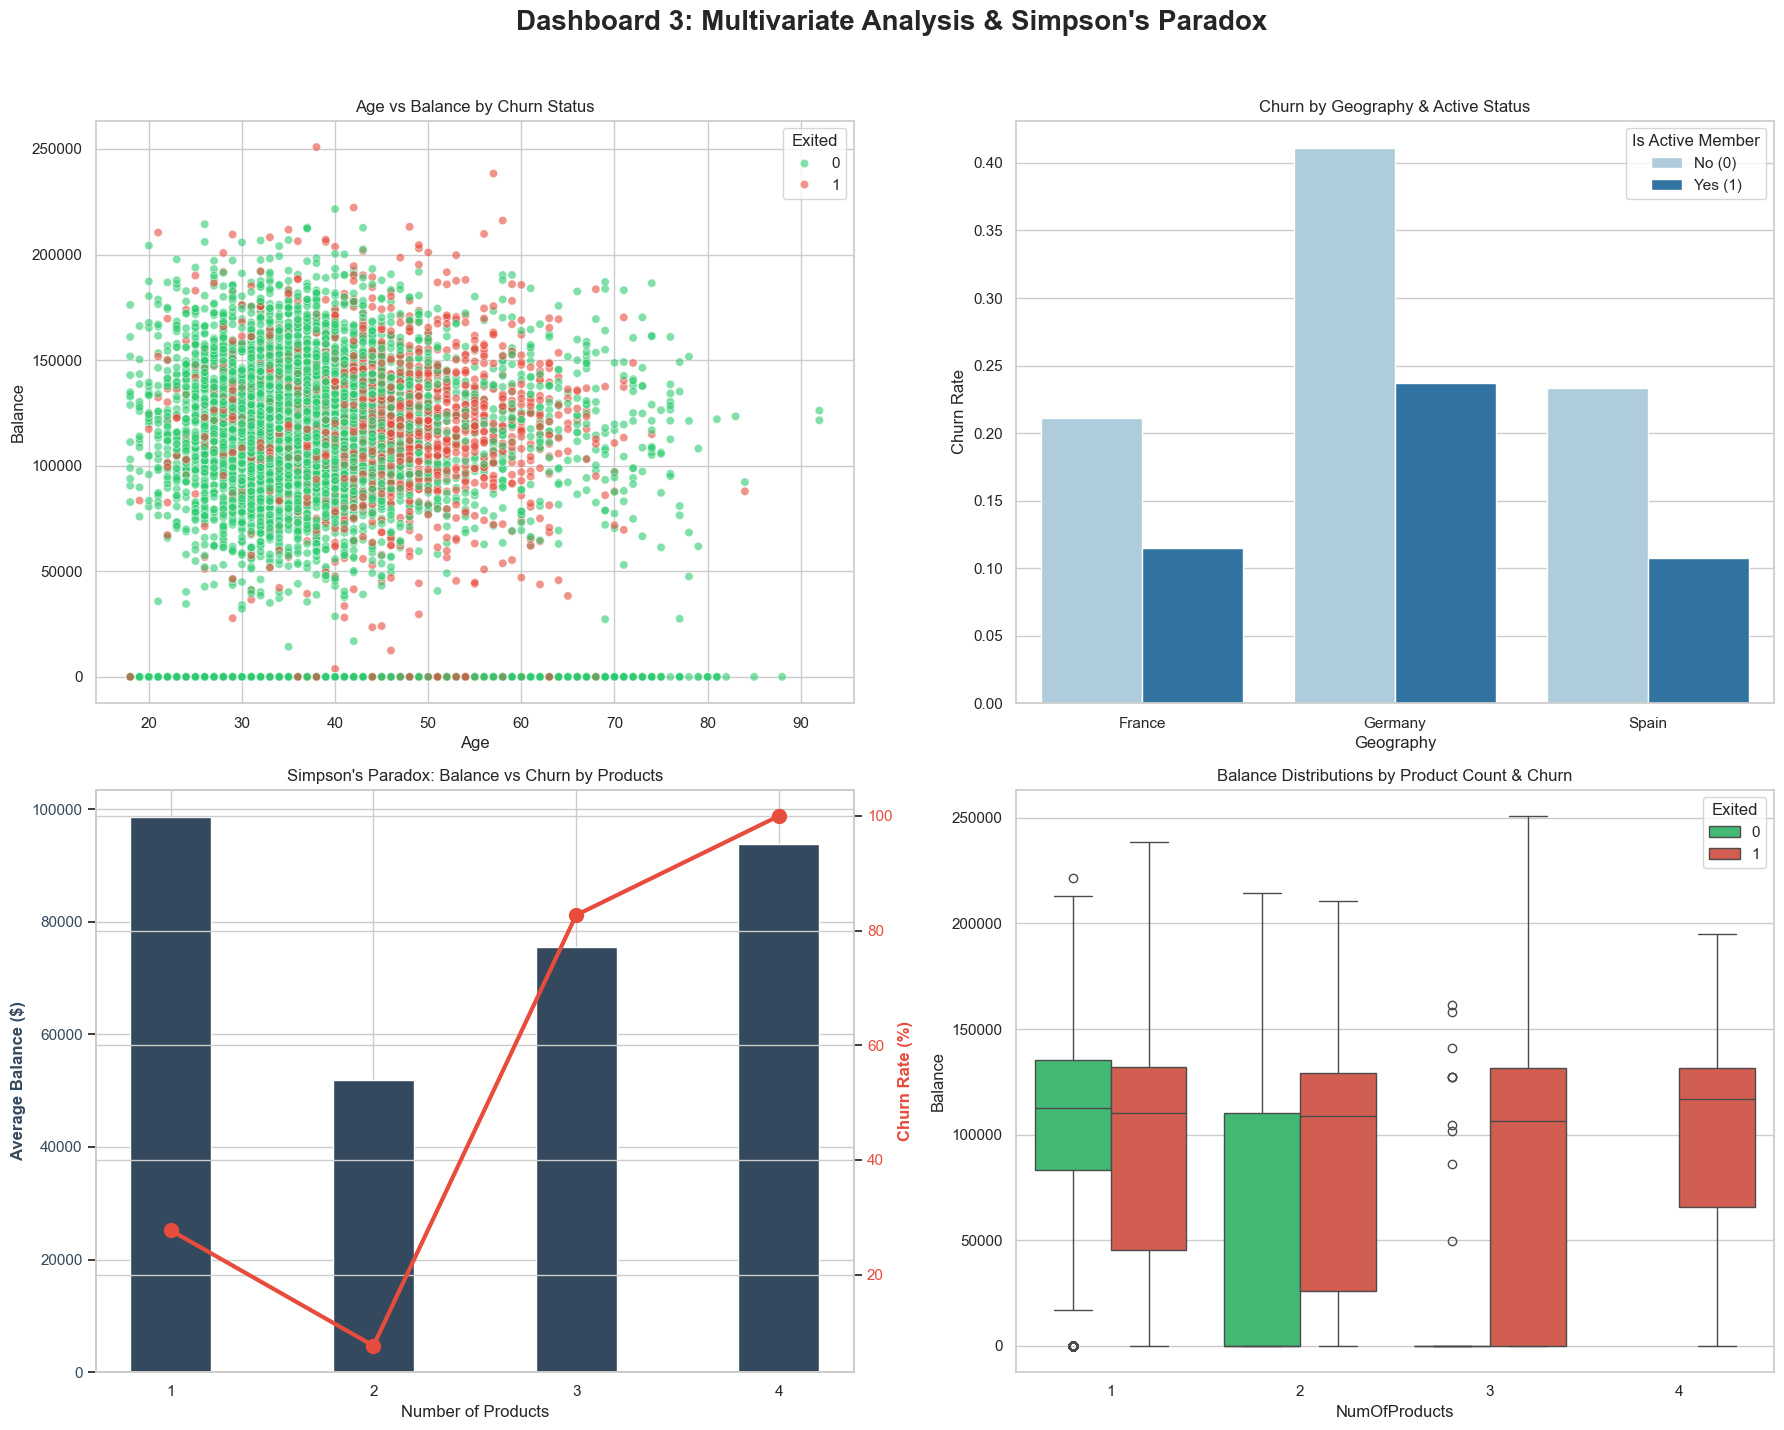

In [51]:
import warnings 
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the dashboards
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the dataset
# Ensure 'Churn_Modelling.csv' is in your working directory
# df = pd.read_csv('Churn_Modelling.csv')

# ==============================================================================
# DASHBOARD 1: UNIVARIATE ANALYSIS (1 Variable)
# ==============================================================================
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 12))
fig1.suptitle('Dashboard 1: Univariate Analysis (Feature Distributions)', fontsize=20, fontweight='bold', y=1.02)

# 1.1 Age Distribution
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue', ax=axes1[0, 0])
axes1[0, 0].set_title('Age Distribution (Right-skewed)')
axes1[0, 0].set_xlabel('Age')

# 1.2 Balance Distribution
sns.histplot(df['Balance'], bins=30, kde=True, color='lightgreen', ax=axes1[0, 1])
axes1[0, 1].set_title('Balance Distribution (Note the spike at $0)')
axes1[0, 1].set_xlabel('Balance ($)')

# 1.3 Target Variable: Churn Rate
churn_counts = df['Exited'].value_counts()
axes1[1, 0].pie(churn_counts, labels=['Retained (0)', 'Exited (1)'], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes1[1, 0].set_title('Overall Churn Proportion (Class Imbalance)')

# 1.4 Number of Products
sns.countplot(x='NumOfProducts', data=df, palette='Blues_d', ax=axes1[1, 1])
axes1[1, 1].set_title('Distribution of Number of Products')

plt.tight_layout()
plt.show()

# ==============================================================================
# DASHBOARD 2: BIVARIATE ANALYSIS (2 Variables vs Target)
# ==============================================================================
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Dashboard 2: Bivariate Analysis (Drivers of Churn)', fontsize=20, fontweight='bold', y=1.02)

# 2.1 Geography vs Churn Rate
geo_churn = df.groupby('Geography')['Exited'].mean().reset_index()
sns.barplot(x='Geography', y='Exited', data=geo_churn, palette='viridis', ax=axes2[0, 0])
axes2[0, 0].set_title('Churn Rate by Geography (Germany is double)')
axes2[0, 0].set_ylabel('Churn Rate')
axes2[0, 0].set_ylim(0, 0.4)

# 2.2 Gender vs Churn Rate
gender_churn = df.groupby('Gender')['Exited'].mean().reset_index()
sns.barplot(x='Gender', y='Exited', data=gender_churn, palette='Set2', ax=axes2[0, 1])
axes2[0, 1].set_title('Churn Rate by Gender (Females churn more)')
axes2[0, 1].set_ylabel('Churn Rate')

# 2.3 Age vs Churn (Boxplot for Outliers/Spread)
sns.boxplot(x='Exited', y='Age', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes2[1, 0])
axes2[1, 0].set_title('Age vs Churn (Churned customers are older)')
axes2[1, 0].set_xticklabels(['Retained', 'Exited'])

# 2.4 Balance vs Churn (Boxplot)
sns.boxplot(x='Exited', y='Balance', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes2[1, 1])
axes2[1, 1].set_title('Balance vs Churn (Higher median balance in churned)')
axes2[1, 1].set_xticklabels(['Retained', 'Exited'])

plt.tight_layout()
plt.show()

# ==============================================================================
# DASHBOARD 3: MULTIVARIATE ANALYSIS & SIMPSON'S PARADOX
# ==============================================================================
fig3, axes3 = plt.subplots(2, 2, figsize=(18, 14))
fig3.suptitle("Dashboard 3: Multivariate Analysis & Simpson's Paradox", fontsize=20, fontweight='bold', y=1.02)

# 3.1 Age vs Balance colored by Churn (Scatter)
sns.scatterplot(x='Age', y='Balance', hue='Exited', palette=['#2ecc71', '#e74c3c'], 
                data=df, alpha=0.6, ax=axes3[0, 0])
axes3[0, 0].set_title('Age vs Balance by Churn Status')

# 3.2 Geography + Active Member Status vs Churn
geo_active = df.groupby(['Geography', 'IsActiveMember'])['Exited'].mean().reset_index()
sns.barplot(x='Geography', y='Exited', hue='IsActiveMember', data=geo_active, palette='Paired', ax=axes3[0, 1])
axes3[0, 1].set_title('Churn by Geography & Active Status')
axes3[0, 1].set_ylabel('Churn Rate')
legend = axes3[0, 1].legend(title='Is Active Member')
legend.get_texts()[0].set_text('No (0)')
legend.get_texts()[1].set_text('Yes (1)')

# 3.3 Simpson's Paradox (Dual Axis on Matplotlib)
agg_df = df.groupby('NumOfProducts').agg(Avg_Balance=('Balance', 'mean'), Churn_Rate=('Exited', 'mean')).reset_index()

ax_bar = axes3[1, 0]
ax_line = ax_bar.twinx() # Create secondary axis for the line

# Bar chart for Balance
ax_bar.bar(agg_df['NumOfProducts'], agg_df['Avg_Balance'], color='#34495e', width=0.4, label='Avg Balance')
ax_bar.set_ylabel('Average Balance ($)', color='#34495e', fontweight='bold')
ax_bar.tick_params(axis='y', labelcolor='#34495e')
ax_bar.set_xlabel('Number of Products')
ax_bar.set_xticks(agg_df['NumOfProducts'])

# Line chart for Churn Rate
ax_line.plot(agg_df['NumOfProducts'], agg_df['Churn_Rate'] * 100, color='#e74c3c', marker='o', linewidth=3, markersize=10, label='Churn Rate')
ax_line.set_ylabel('Churn Rate (%)', color='#e74c3c', fontweight='bold')
ax_line.tick_params(axis='y', labelcolor='#e74c3c')

axes3[1, 0].set_title("Simpson's Paradox: Balance vs Churn by Products")

# 3.4 Outlier Analysis Context: Balance by Number of Products and Churn
sns.boxplot(x='NumOfProducts', y='Balance', hue='Exited', palette=['#2ecc71', '#e74c3c'], data=df, ax=axes3[1, 1])
axes3[1, 1].set_title('Balance Distributions by Product Count & Churn')

plt.tight_layout()
plt.show()

In [52]:
print('''
continuous  | categorical | categorical --> bar + point/line 
continuous  | continuous  | categorical --> scatter 
categorical | categorical | categorical --> bar(output variable will be converted to continuous)
''')


continuous  | categorical | categorical --> bar + point/line 
continuous  | continuous  | categorical --> scatter 
categorical | categorical | categorical --> bar(output variable will be converted to continuous)



In [53]:
cat_features, descrete_features, continuous_features

(['Geography', 'Gender'],
 ['Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember'],
 ['CreditScore', 'Age', 'Balance', 'EstimatedSalary'])

In [54]:
def create_multivariate_chart(
    nrows: int, 
    ncols: int, 
    df: pd.DataFrame, 
    features_combination_for_ploting: Iterable, 
    cat_features: Iterable, 
    descrete_features: Iterable, 
    continuous_features: Iterable, 
    target_feature: str, 
    dict_palette: dict[str, str], 
    path: str = "reports/Multivariate Analysis.png", 
    figsize: tuple = (30, 30), 
    header_fontsize: int = 20
): 
    # Multivariate Analysis
    fig, axis = plt.subplots(nrows, ncols, figsize=figsize)
    descat_features = (cat_features + descrete_features)
    fig.suptitle("Multivariate Analysis", fontsize=header_fontsize, fontweight="bold", color="brown", fontstyle="oblique", y=1)
    idx=0
    stop=False
    for row in range(nrows):
        for col in range(ncols):
            features = features_combination_for_ploting[idx]
            ax = axis[row, col]
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if not len(features)==2: 
                raise ValueError('provided tuple of features must have len of 2 only as target feature will itself be third.')
            if features[0] in continuous_features and features[1] in descat_features or features[1] in continuous_features and features[0] in descat_features: 
                cont_feature, cat_feature = [feature for feature in features if feature in continuous_features][0], [feature for feature in features if feature in descat_features][0]
                line_ax = ax.twinx()
                sns.barplot(
                    df, 
                    x=cat_feature, 
                    y=cont_feature, 
                    hue=cat_feature, 
                    palette=dict_palette, 
                    legend=False,
                    ax=ax
                )
                agg_data = df.groupby(cat_feature)['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})
                sns.pointplot(
                    agg_data,
                    x=cat_feature, 
                    y='Churn Rate', 
                    hue=cat_feature,  
                    color='black', 
                    legend=False, 
                    marker='o', 
                    # markersize=10, 
                    ax=line_ax 
                )
                # line_ax.plot(agg_data[cat_feature], agg_data['Churn Rate'] * 100, color='#e74c3c', marker='o', linewidth=3, markersize=10, label='Churn Rate')
                # line_ax.set_ylabel('Churn Rate (%)', color='#e74c3c', fontweight='bold')
                # line_ax.tick_params(axis='y', labelcolor='#e74c3c')
            elif features[0] in continuous_features and features[1] in continuous_features: 
                sns.scatterplot(
                    df, 
                    x=features[0], 
                    y=features[1], 
                    hue=target_feature, 
                    palette=dict_palette, 
                    ax=ax
                )
            elif features[0] in descat_features and features[1] in descat_features: 
                agg_data = df.groupby(list(features))['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})
                sns.barplot(
                    agg_data, 
                    x=features[0], 
                    y='Churn Rate', 
                    hue=features[1], 
                    palette=dict_palette, 
                    ax=ax 
                ) 
            else: 
                raise ValueError('Provided tuple of features don\'t belongs to predifined combinations.')
            idx+=1
            if (len(features_combination_for_ploting))==idx:
                stop=True
                break
        if stop:
            break
    for row in axis:
        for ax in row:
            if not ax.has_data():
                ax.remove()
    plt.tight_layout()

    # Save a high-resolution, neatly framed, transparent PNG file
    plt.savefig(path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show() 

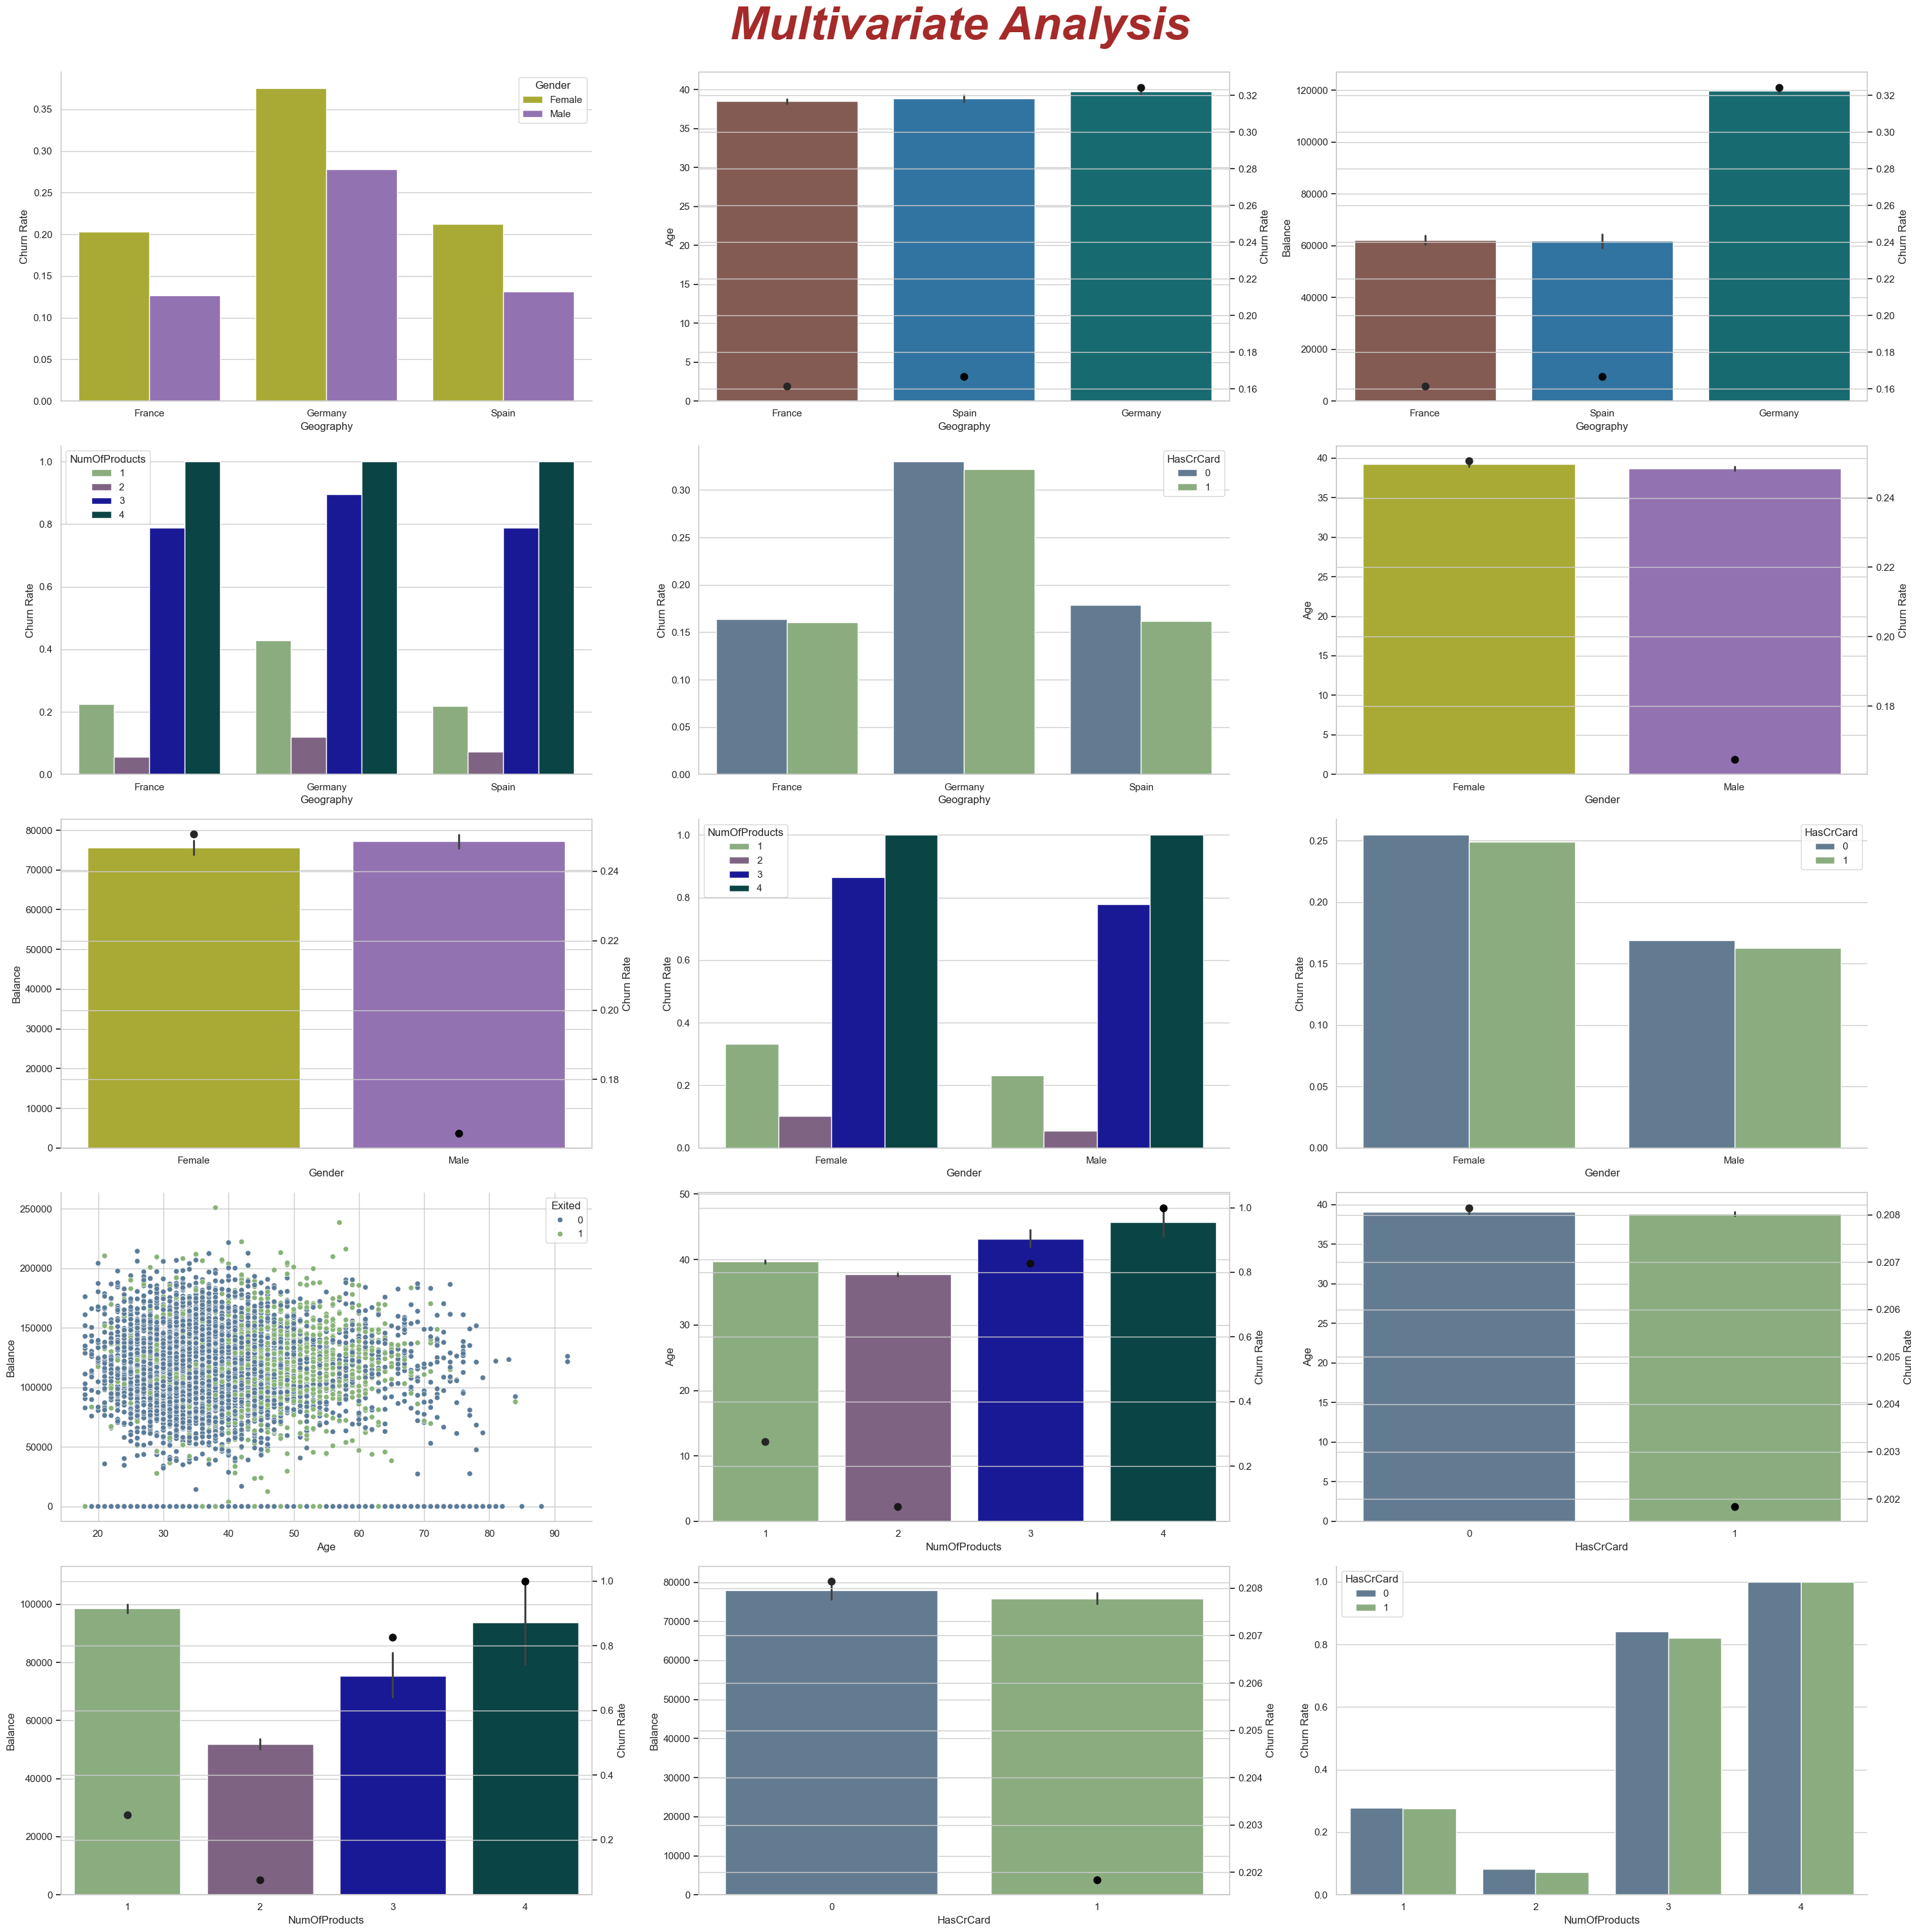

In [55]:
nrows, ncols =  math.ceil((len(cols_combinations))/3), 3

create_multivariate_chart(
    nrows = nrows, 
    ncols = ncols, 
    df = df, 
    features_combination_for_ploting = cols_combinations, 
    cat_features = cat_features, 
    descrete_features = descrete_features, 
    continuous_features = continuous_features, 
    target_feature = target_feature, 
    dict_palette = dict_palette, 
    header_fontsize = 52
)

In [56]:
'''(Balance, Geography, Churn Rate), (Balance, Age, Exited)'''

'(Balance, Geography, Churn Rate), (Balance, Age, Exited)'

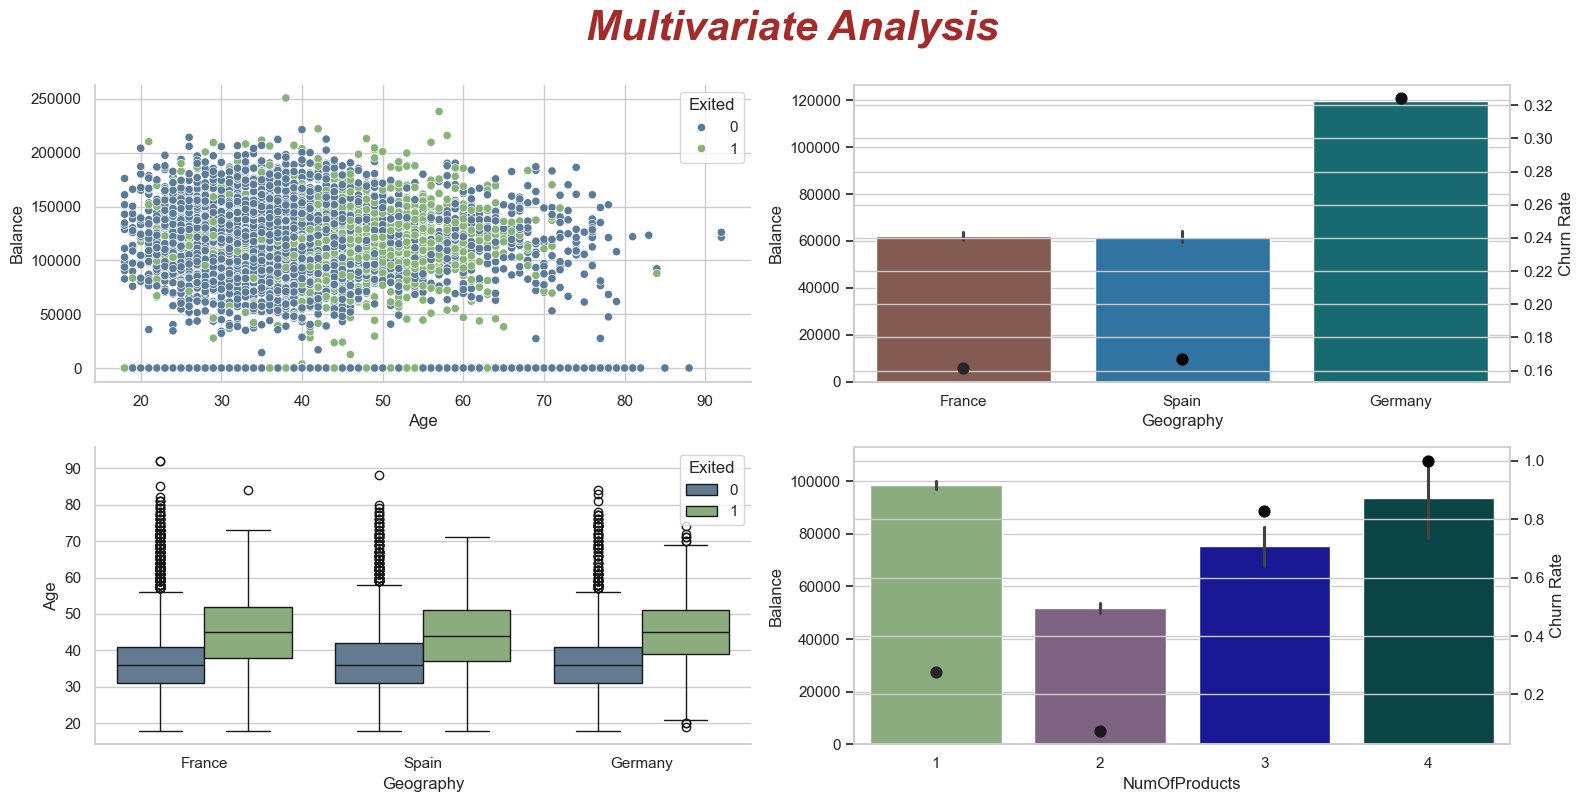

In [57]:
# Multivariate Analysis
fig, axis = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle("Multivariate Analysis", fontsize=30, fontweight="bold", color="brown", fontstyle="oblique", y=1)
# plot 1
ax = axis[0, 0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.scatterplot(
    df, 
    x='Age', 
    y='Balance', 
    hue=target_feature, 
    palette=dict_palette, 
    ax=ax
)
# plot 2
ax = axis[0, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
line_ax = ax.twinx()
sns.barplot(
    df, 
    x='Geography', 
    y='Balance', 
    hue='Geography', 
    palette=dict_palette, 
    legend=False,
    ax=ax
)
agg_data = df.groupby('Geography')['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})
sns.pointplot(
    agg_data,
    x='Geography', 
    y='Churn Rate', 
    hue='Geography',  
    color='black', 
    legend=False, 
    marker='o', 
    ax=line_ax 
)
# plot 3
ax = axis[1, 0]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.boxplot(
    df, 
    x='Geography', 
    y='Age', 
    hue=target_feature, 
    palette=dict_palette, 
    ax=ax 
)
# plot 4
ax = axis[1, 1]
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
line_ax = ax.twinx()
sns.barplot(
    df, 
    x='NumOfProducts', 
    y='Balance', 
    hue='NumOfProducts', 
    palette=dict_palette, 
    legend=False, 
    ax=ax 
)
agg_data = df.groupby('NumOfProducts')['Exited'].aggregate('mean').reset_index().rename(columns={'Exited':'Churn Rate'})
sns.pointplot(
    agg_data,
    x='NumOfProducts', 
    y='Churn Rate', 
    hue='NumOfProducts',  
    color='black', 
    legend=False, 
    marker='o', 
    ax=line_ax 
)
for row in axis:
    for ax in row:
        if not ax.has_data():
            ax.remove()
plt.tight_layout()

# Save a high-resolution, neatly framed, transparent PNG file
plt.savefig('reports/Multivariate Analysis Final Dashboard.png', dpi=300, bbox_inches="tight", transparent=True)

plt.show() 

#### Observation 

When segmenting Geography by age, balance & churn rate, Germany have customer with high balance with older demographics where all three factors indicates towards higher churn.

In [58]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [59]:
import numpy as np 

In [60]:
np.__version__

'2.4.2'

In [61]:
Q1, median, Q3 = np.percentile(
    df['Age'], 
    [25, 50, 75]
)
Q1, median, Q3

(np.float64(32.0), np.float64(37.0), np.float64(44.0))

In [62]:
df['Age'].median()

np.float64(37.0)

In [63]:
IQR = Q3 - Q1 
IQR

np.float64(12.0)

In [64]:
higher_fence, lower_fence =  Q3+(1.5*IQR), Q3-(1.5*IQR) 
higher_fence, lower_fence

(np.float64(62.0), np.float64(26.0))

<Axes: ylabel='Age'>

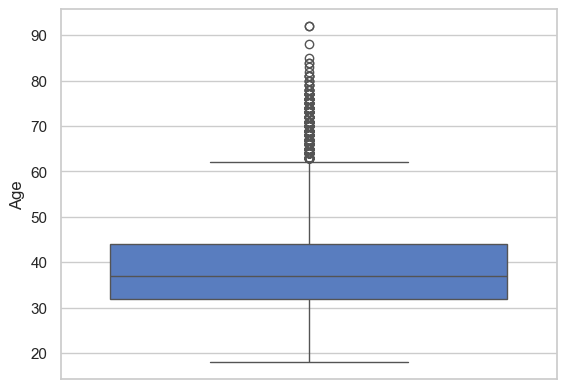

In [65]:
import seaborn as sns 

sns.boxplot(df, y='Age')